In [2]:
# Install and load dataset
# No CSV download needed — loads directly in one line!

!pip install ucimlrepo -q

from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Fetch directly from UCI
print("Fetching Maternal Health Risk dataset from UCI...")
maternal = fetch_ucirepo(id=863)

X = maternal.data.features
y = maternal.data.targets

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

print("Dataset loaded!")
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Fetching Maternal Health Risk dataset from UCI...
Dataset loaded!

Shape: (1014, 7)

Columns: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel']

First 5 rows:


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [3]:
# Understand what we have

print("=== Dataset Info ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Risk Level Distribution ===")
print(df['RiskLevel'].value_counts())

print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Dataset Info ===
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

=== Missing Values ===
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

=== Risk Level Distribution ===
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

=== Basic Statistics ===


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.00,1014.0,1014.00,1014.00,1014.00,1014.00
mean,29.87,113.2,76.46,8.73,98.67,74.30
std,13.47,18.4,13.89,3.29,1.37,8.09
min,10.00,70.0,49.00,6.00,98.00,7.00
25%,19.00,100.0,65.00,6.90,98.00,70.00
50%,26.00,120.0,80.00,7.50,98.00,76.00
75%,39.00,120.0,90.00,8.00,98.00,80.00
max,70.00,160.0,100.00,19.00,103.00,90.00


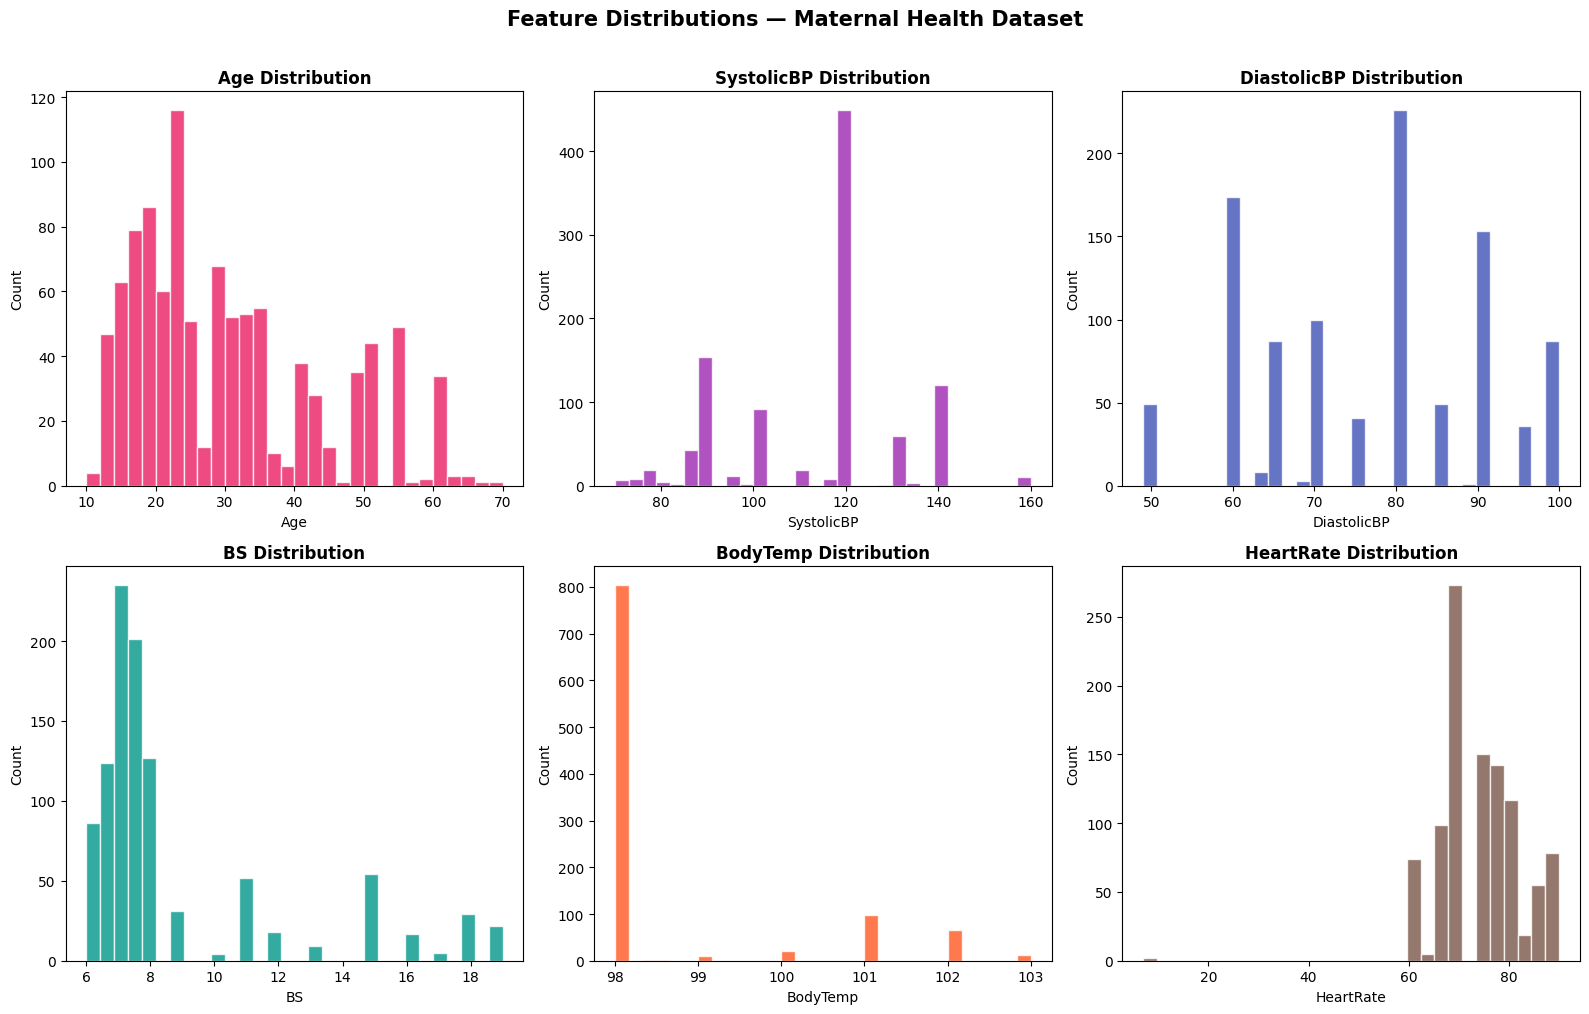

In [4]:
# Visual EDA

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

features  = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']
colors    = ['#E91E63', '#9C27B0', '#3F51B5', '#009688', '#FF5722', '#795548']

for i, (feat, color) in enumerate(zip(features, colors)):
    row, col = divmod(i, 3)
    axes[row][col].hist(
        df[feat], bins=30,
        color=color, alpha=0.8, edgecolor='white'
    )
    axes[row][col].set_title(
        f'{feat} Distribution',
        fontsize=12, fontweight='bold'
    )
    axes[row][col].set_xlabel(feat)
    axes[row][col].set_ylabel('Count')

plt.suptitle(
    'Feature Distributions — Maternal Health Dataset',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

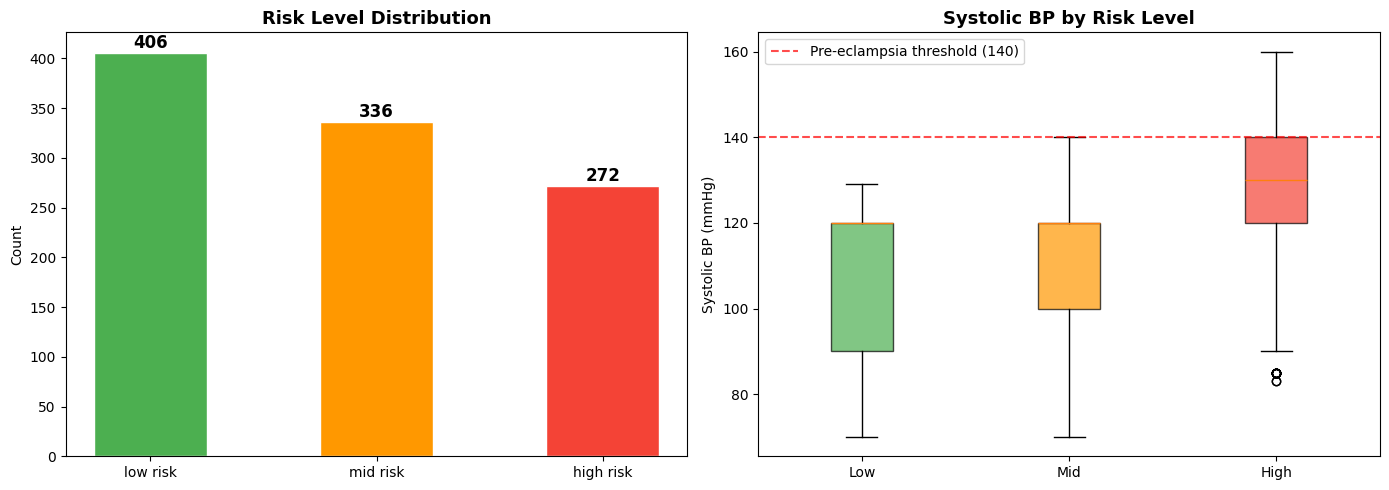

=== BP Statistics by Risk Level ===
           count   mean   std   min    25%    50%    75%    max
RiskLevel                                                      
high risk  272.0  124.2  20.2  83.0  120.0  130.0  140.0  160.0
low risk   406.0  105.9  15.9  70.0   90.0  120.0  120.0  129.0
mid risk   336.0  113.2  15.0  70.0  100.0  120.0  120.0  140.0


In [5]:
# Risk level distribution and per-feature breakdown

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Risk level counts
colors    = ['#4CAF50', '#FF9800', '#F44336']
risk_counts = df['RiskLevel'].value_counts()

bars = axes[0].bar(
    risk_counts.index, risk_counts.values,
    color=colors, edgecolor='white', width=0.5
)
for bar, cnt in zip(bars, risk_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        str(cnt),
        ha='center', fontsize=12, fontweight='bold'
    )
axes[0].set_title('Risk Level Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# Plot 2 — BP by risk level
risk_order = ['low risk', 'mid risk', 'high risk']
bp_by_risk = [
    df[df['RiskLevel']==r]['SystolicBP'].values
    for r in risk_order
]
bp = axes[1].boxplot(
    bp_by_risk,
    labels=['Low', 'Mid', 'High'],
    patch_artist=True
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title(
    'Systolic BP by Risk Level',
    fontsize=13, fontweight='bold'
)
axes[1].set_ylabel('Systolic BP (mmHg)')
axes[1].axhline(
    y=140, color='red',
    linestyle='--', alpha=0.7,
    label='Pre-eclampsia threshold (140)'
)
axes[1].legend()

plt.tight_layout()
plt.savefig('risk_analysis.png', dpi=150)
plt.show()

print("=== BP Statistics by Risk Level ===")
print(df.groupby('RiskLevel')['SystolicBP'].describe().round(1))

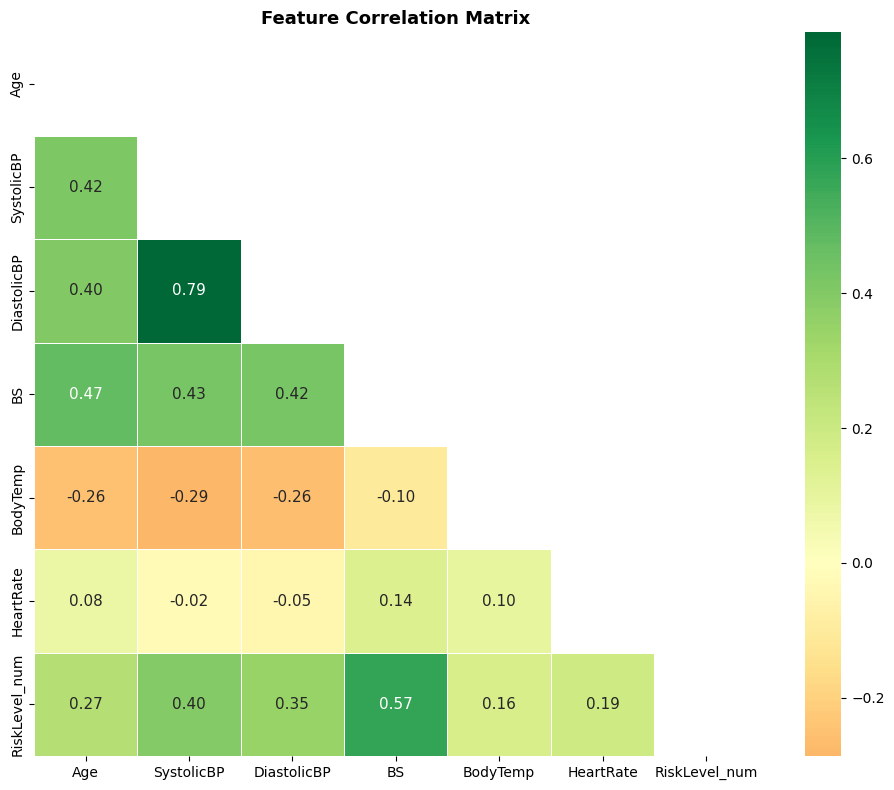

=== Correlation with Risk Level ===
RiskLevel_num    1.000
BS               0.570
SystolicBP       0.396
DiastolicBP      0.347
Age              0.267
HeartRate        0.194
BodyTemp         0.164
Name: RiskLevel_num, dtype: float64


In [6]:
# Feature correlations

# Encode risk level for correlation
df_corr = df.copy()
risk_map = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df_corr['RiskLevel_num'] = df_corr['RiskLevel'].map(risk_map)

plt.figure(figsize=(10, 8))
corr_matrix = df_corr.drop('RiskLevel', axis=1).corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 11}
)
plt.title(
    'Feature Correlation Matrix',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

print("=== Correlation with Risk Level ===")
print(
    df_corr.drop('RiskLevel', axis=1)
    .corr()['RiskLevel_num']
    .sort_values(ascending=False)
    .round(3)
)

In [7]:
# Save base cleaned dataset
# Standardize risk level labels
df['RiskLevel'] = df['RiskLevel'].str.strip().str.lower()

print("Risk level values:", df['RiskLevel'].unique())
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())

df.to_csv('maternal_base.csv', index=False)
print("\nBase dataset saved!")

Risk level values: ['high risk' 'low risk' 'mid risk']
Shape: (1014, 7)
Missing values: 0

Base dataset saved!


In [8]:
# Add ASHA-specific features using domain knowledge
# These features don't exist in base dataset but are
# critical for rural India context

import pandas as pd
import numpy as np

df = pd.read_csv('maternal_base.csv')

np.random.seed(42)
n = len(df)

# Encode risk for guided generation
risk_map     = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
risk_encoded = df['RiskLevel'].map(risk_map).values

# ── 1. Haemoglobin (g/dL) ─────────────────────────────────────
# High risk → lower Hb (anaemia common)
# Low risk  → normal Hb
hb_means = {0: 11.5, 1: 10.2, 2: 8.8}
hb_stds  = {0: 1.2,  1: 1.5,  2: 1.8}

haemoglobin = np.array([
    np.clip(
        np.random.normal(hb_means[r], hb_stds[r]),
        5.0, 15.0
    )
    for r in risk_encoded
])
df['Haemoglobin'] = haemoglobin.round(1)

# ── 2. Gestational Age (weeks) ────────────────────────────────
# High risk → more spread (preterm + late term)
# Low risk  → mostly 28-36 weeks
gest_means = {0: 28.0, 1: 32.0, 2: 35.0}
gest_stds  = {0: 6.0,  1: 7.0,  2: 8.0}

gestational_age = np.array([
    np.clip(
        np.random.normal(gest_means[r], gest_stds[r]),
        8.0, 42.0
    )
    for r in risk_encoded
])
df['GestationalAge'] = gestational_age.round(0).astype(int)

# ── 3. Parity (number of previous pregnancies) ────────────────
# High risk → more likely high parity (4+) or primipara (0)
parity_probs = {
    0: [0.25, 0.40, 0.25, 0.10],   # low risk
    1: [0.20, 0.35, 0.30, 0.15],   # mid risk
    2: [0.15, 0.25, 0.30, 0.30]    # high risk — more 3+
}

parity = np.array([
    np.random.choice([0, 1, 2, 3], p=parity_probs[r])
    for r in risk_encoded
])
df['Parity'] = parity

# ── 4. Oedema (0 = No, 1 = Yes) ──────────────────────────────
# High risk → 65% have oedema (pre-eclampsia signal)
# Low risk  → 10% have oedema
oedema_probs = {0: 0.10, 1: 0.35, 2: 0.65}

oedema = np.array([
    np.random.binomial(1, oedema_probs[r])
    for r in risk_encoded
])
df['Oedema'] = oedema

# ── 5. Previous Complications (0 = No, 1 = Yes) ──────────────
# Past C-section, miscarriage, stillbirth
comp_probs = {0: 0.08, 1: 0.25, 2: 0.55}

prev_comp = np.array([
    np.random.binomial(1, comp_probs[r])
    for r in risk_encoded
])
df['PreviousComplications'] = prev_comp

# ── 6. Distance to Hospital (km) ─────────────────────────────
# High risk in remote areas → further distance
# Affects urgency of referral
dist_means = {0: 8.0,  1: 15.0, 2: 25.0}
dist_stds  = {0: 5.0,  1: 10.0, 2: 15.0}

distance = np.array([
    np.clip(
        np.random.normal(dist_means[r], dist_stds[r]),
        1.0, 80.0
    )
    for r in risk_encoded
])
df['DistanceToHospital'] = distance.round(1)

# ── 7. Weight Gain (kg in last month) ────────────────────────
# Excessive weight gain → pre-eclampsia signal
wt_means = {0: 1.5, 1: 2.5, 2: 3.8}
wt_stds  = {0: 0.8, 1: 1.2, 2: 1.5}

weight_gain = np.array([
    np.clip(
        np.random.normal(wt_means[r], wt_stds[r]),
        0.0, 8.0
    )
    for r in risk_encoded
])
df['WeightGain'] = weight_gain.round(1)

print("New columns added:")
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nSample of new features:")
print(df[['Haemoglobin','GestationalAge','Parity',
          'Oedema','PreviousComplications',
          'DistanceToHospital','WeightGain',
          'RiskLevel']].head(8))

New columns added:
['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate', 'RiskLevel', 'Haemoglobin', 'GestationalAge', 'Parity', 'Oedema', 'PreviousComplications', 'DistanceToHospital', 'WeightGain']

Shape: (1014, 14)

Sample of new features:
   Haemoglobin  GestationalAge  Parity  Oedema  PreviousComplications  \
0          9.7              42       0       1                      1   
1          8.6              37       2       1                      1   
2         10.0              30       1       1                      0   
3         11.5              31       3       1                      0   
4         11.2              26       2       0                      0   
5          8.4              38       3       1                      0   
6         12.6              36       2       1                      1   
7         10.2              30       2       1                      0   

   DistanceToHospital  WeightGain  RiskLevel  
0                11.8         3.7  hi

In [9]:
#  Validate features make clinical sense

print("=== Clinical Validation of Engineered Features ===\n")

features_to_check = {
    'Haemoglobin':          ('lower = more anaemia = higher risk', True),
    'Oedema':               ('more oedema in high risk', False),
    'PreviousComplications': ('more complications in high risk', False),
    'WeightGain':           ('more weight gain in high risk', False),
    'DistanceToHospital':   ('further = higher risk area', False)
}

for feat, (desc, lower_is_worse) in features_to_check.items():
    means = df.groupby('RiskLevel')[feat].mean()
    low   = means.get('low risk', 0)
    mid   = means.get('mid risk', 0)
    high  = means.get('high risk', 0)
    print(f"[{feat}] — {desc}")
    print(f"  Low risk:  {low:.2f}")
    print(f"  Mid risk:  {mid:.2f}")
    print(f"  High risk: {high:.2f}")

    if lower_is_worse:
        trend = "CORRECT" if high < mid < low else "CHECK"
    else:
        trend = "CORRECT" if high > mid > low else "CHECK"

    print(f"  Trend: {trend}\n")

# Save
df.to_csv('maternal_engineered.csv', index=False)
print("Saved maternal_engineered.csv!")

=== Clinical Validation of Engineered Features ===

[Haemoglobin] — lower = more anaemia = higher risk
  Low risk:  11.55
  Mid risk:  10.20
  High risk: 8.86
  Trend: CORRECT

[Oedema] — more oedema in high risk
  Low risk:  0.09
  Mid risk:  0.31
  High risk: 0.59
  Trend: CORRECT

[PreviousComplications] — more complications in high risk
  Low risk:  0.08
  Mid risk:  0.24
  High risk: 0.59
  Trend: CORRECT

[WeightGain] — more weight gain in high risk
  Low risk:  1.46
  Mid risk:  2.48
  High risk: 3.76
  Trend: CORRECT

[DistanceToHospital] — further = higher risk area
  Low risk:  8.02
  Mid risk:  15.60
  High risk: 24.66
  Trend: CORRECT

Saved maternal_engineered.csv!


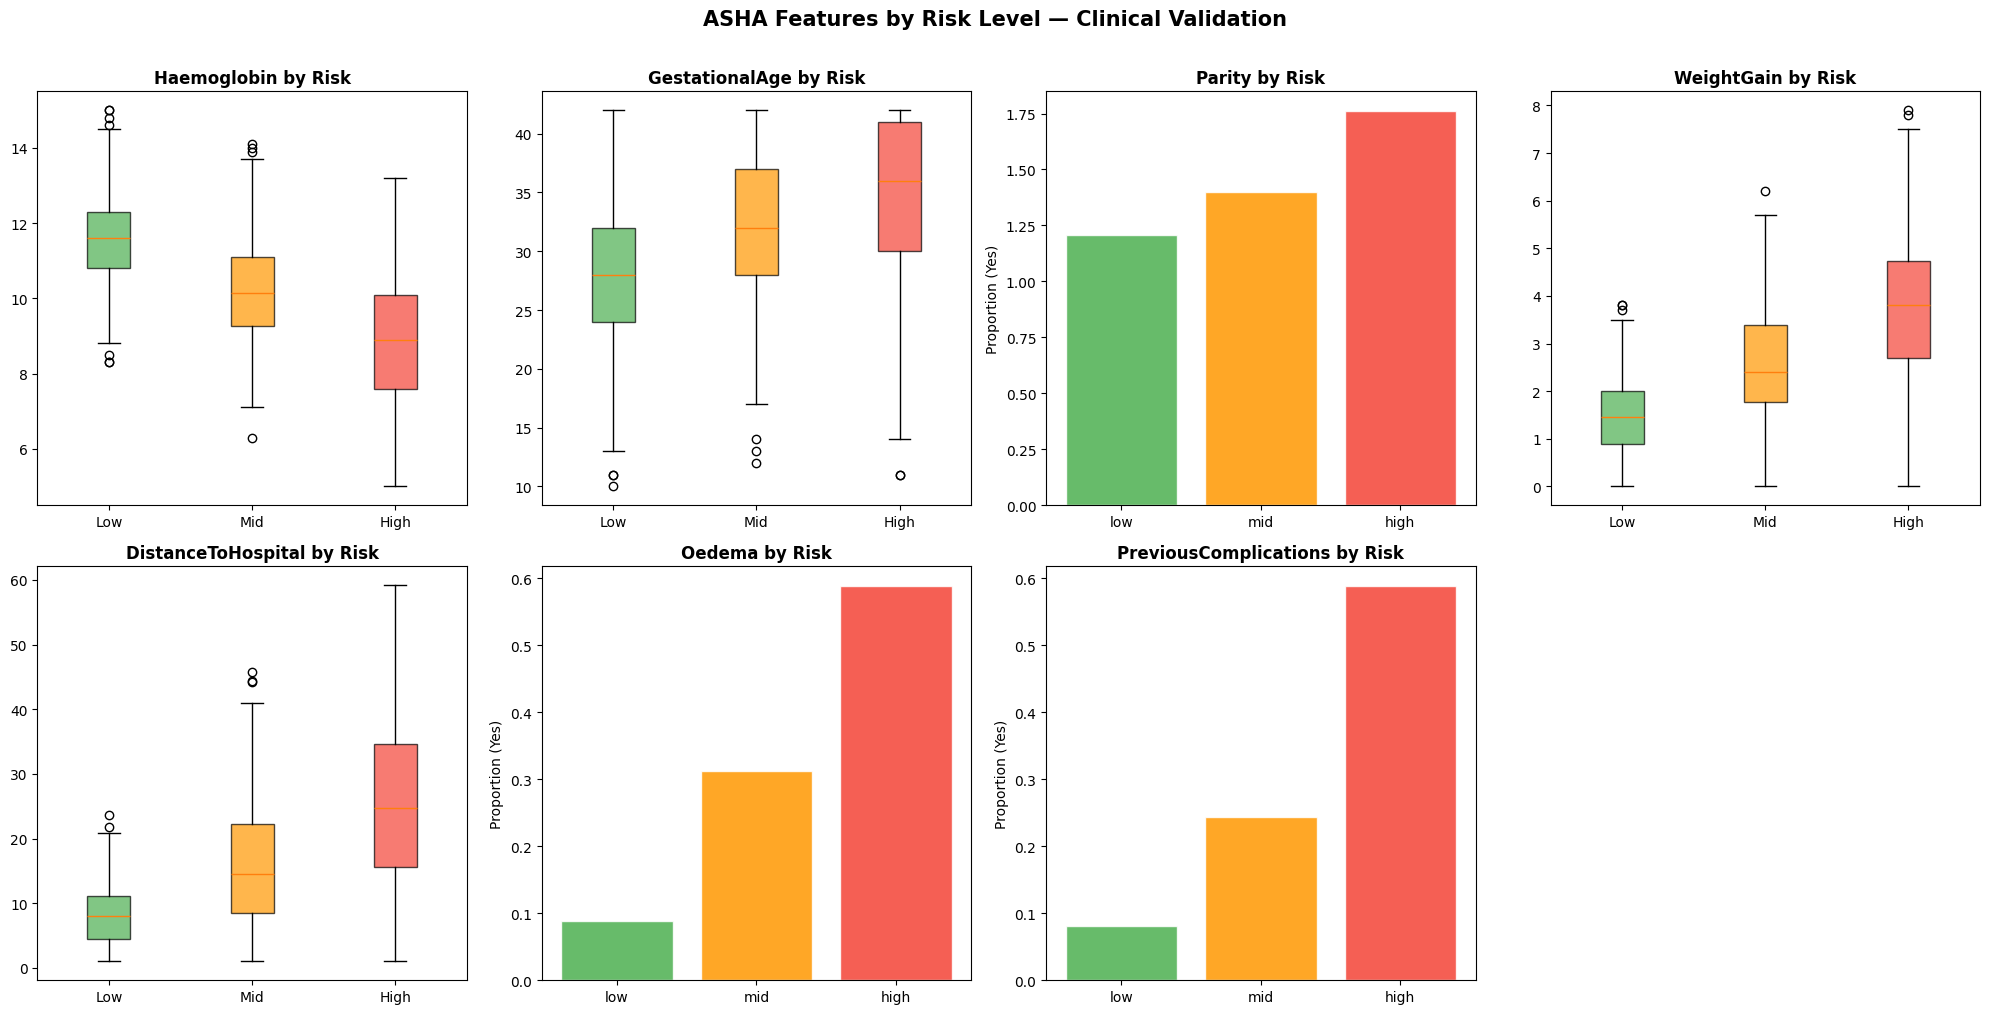

In [10]:
# Visualize ASHA features by risk level

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes      = axes.flatten()

new_features = [
    'Haemoglobin', 'GestationalAge', 'Parity',
    'WeightGain', 'DistanceToHospital',
    'Oedema', 'PreviousComplications'
]
colors = ['#4CAF50', '#FF9800', '#F44336']
risks  = ['low risk', 'mid risk', 'high risk']

for i, feat in enumerate(new_features):
    if df[feat].nunique() <= 4:   # categorical
        for j, (risk, color) in enumerate(zip(risks, colors)):
            val = df[df['RiskLevel']==risk][feat].mean()
            axes[i].bar(
                risk.replace(' risk',''),
                val, color=color,
                edgecolor='white', alpha=0.85
            )
        axes[i].set_title(
            f'{feat} by Risk', fontweight='bold'
        )
        axes[i].set_ylabel('Proportion (Yes)')
    else:
        data = [
            df[df['RiskLevel']==r][feat].values
            for r in risks
        ]
        bp = axes[i].boxplot(
            data,
            labels=['Low','Mid','High'],
            patch_artist=True
        )
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        axes[i].set_title(
            f'{feat} by Risk', fontweight='bold'
        )

axes[-1].axis('off')
plt.suptitle(
    'ASHA Features by Risk Level — Clinical Validation',
    fontsize=15, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('asha_features.png', dpi=150)
plt.show()

In [11]:
# Encode labels and split data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df = pd.read_csv('maternal_engineered.csv')

# Encode risk level
le = LabelEncoder()
df['label'] = le.fit_transform(df['RiskLevel'])
# 0=high risk, 1=low risk, 2=mid risk
# We'll fix ordering below

# Manual mapping for correct clinical order
risk_order = {'low risk': 0, 'mid risk': 1, 'high risk': 2}
df['label'] = df['RiskLevel'].map(risk_order)

print("Label mapping:")
for k, v in risk_order.items():
    print(f"  {v} → {k}")

feature_cols = [
    'Age', 'SystolicBP', 'DiastolicBP', 'BS',
    'BodyTemp', 'HeartRate', 'Haemoglobin',
    'GestationalAge', 'Parity', 'Oedema',
    'PreviousComplications', 'DistanceToHospital',
    'WeightGain'
]

X = df[feature_cols]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale features
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")
print(f"Features: {len(feature_cols)}")
print(f"\nClass distribution (train):")
print(pd.Series(y_train).value_counts().sort_index())

Label mapping:
  0 → low risk
  1 → mid risk
  2 → high risk

Train: 811 | Test: 203
Features: 13

Class distribution (train):
label
0    325
1    269
2    217
Name: count, dtype: int64


In [13]:
# Train 5 baseline models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', class_weight='balanced',
        random_state=42, probability=True
    ),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

results = {}
print("Training baseline models...\n")

for name, mdl in models.items():
    start  = time.time()
    mdl.fit(X_train_sc, y_train)
    preds  = mdl.predict(X_test_sc)
    acc    = accuracy_score(y_test, preds)
    elapsed= time.time() - start

    results[name] = {
        'model': mdl, 'preds': preds,
        'accuracy': acc, 'time': elapsed
    }
    print(f"[{name}]")
    print(f"  Accuracy: {acc*100:.2f}% | Time: {elapsed:.1f}s")
    print(f"  Report:")
    print(classification_report(
        y_test, preds,
        target_names=['Low','Mid','High']
    ))

Training baseline models...

[Logistic Regression]
  Accuracy: 81.77% | Time: 0.1s
  Report:
              precision    recall  f1-score   support

         Low       0.85      0.81      0.83        81
         Mid       0.72      0.75      0.74        67
        High       0.89      0.91      0.90        55

    accuracy                           0.82       203
   macro avg       0.82      0.82      0.82       203
weighted avg       0.82      0.82      0.82       203

[Random Forest]
  Accuracy: 84.73% | Time: 1.7s
  Report:
              precision    recall  f1-score   support

         Low       0.84      0.84      0.84        81
         Mid       0.78      0.78      0.78        67
        High       0.95      0.95      0.95        55

    accuracy                           0.85       203
   macro avg       0.85      0.85      0.85       203
weighted avg       0.85      0.85      0.85       203

[Gradient Boosting]
  Accuracy: 86.70% | Time: 2.7s
  Report:
              precision  

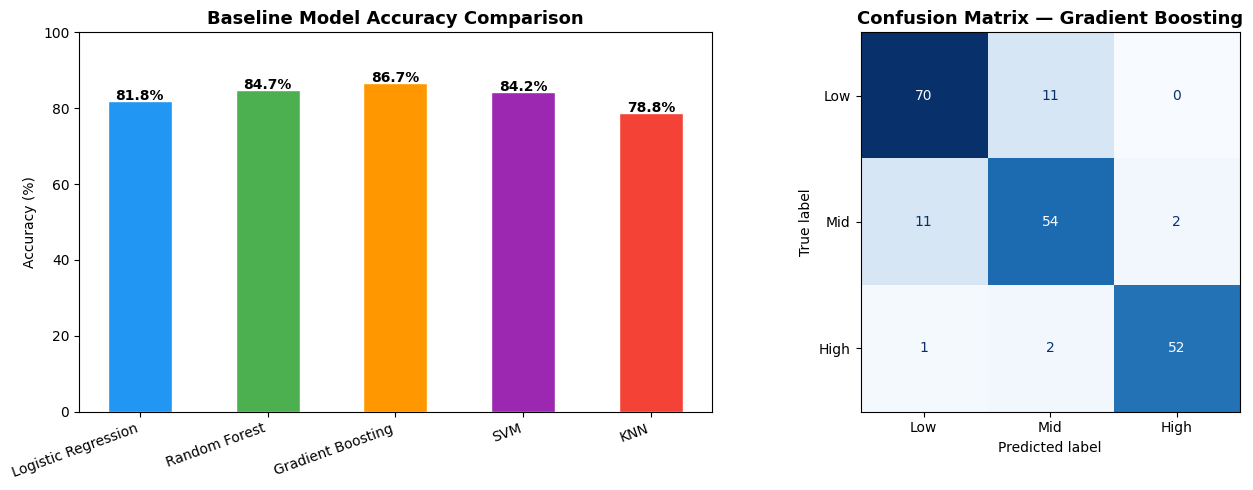


Best baseline: Gradient Boosting
Best accuracy: 86.70%


In [14]:
# Visual comparison

import matplotlib.pyplot as plt

names = list(results.keys())
accs  = [results[n]['accuracy']*100 for n in names]
colors_bar = [
    '#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bars
bars = axes[0].bar(
    names, accs,
    color=colors_bar, edgecolor='white', width=0.5
)
for bar, acc in zip(bars, accs):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{acc:.1f}%',
        ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_title(
    'Baseline Model Accuracy Comparison',
    fontsize=13, fontweight='bold'
)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].set_xticklabels(names, rotation=20, ha='right')

# Confusion matrix of best model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_name = max(results, key=lambda x: results[x]['accuracy'])
best_preds= results[best_name]['preds']
cm        = confusion_matrix(y_test, best_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low','Mid','High']
)
disp.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title(
    f'Confusion Matrix — {best_name}',
    fontsize=13, fontweight='bold'
)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150)
plt.show()

print(f"\nBest baseline: {best_name}")
print(f"Best accuracy: {results[best_name]['accuracy']*100:.2f}%")

In [15]:
# XGBoost (usually best for tabular medical data)

!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_test_sc, y_test)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test_sc)
xgb_acc   = accuracy_score(y_test, xgb_preds)

print(f"XGBoost Accuracy: {xgb_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(
    y_test, xgb_preds,
    target_names=['Low Risk','Mid Risk','High Risk']
))

Training XGBoost...
XGBoost Accuracy: 85.71%

Detailed Report:
              precision    recall  f1-score   support

    Low Risk       0.85      0.86      0.86        81
    Mid Risk       0.79      0.79      0.79        67
   High Risk       0.94      0.93      0.94        55

    accuracy                           0.86       203
   macro avg       0.86      0.86      0.86       203
weighted avg       0.86      0.86      0.86       203



In [16]:
# Voting ensemble of top 3 models

from sklearn.ensemble import VotingClassifier

# Pick top 3 from baseline + XGBoost
ensemble = VotingClassifier(
    estimators=[
        ('rf',  results['Random Forest']['model']),
        ('gb',  results['Gradient Boosting']['model']),
        ('xgb', xgb_model)
    ],
    voting='soft'   # uses probabilities — better than hard voting
)

print("Training Voting Ensemble...")
ensemble.fit(X_train_sc, y_train)
ens_preds = ensemble.predict(X_test_sc)
ens_acc   = accuracy_score(y_test, ens_preds)

print(f"Ensemble Accuracy: {ens_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(
    y_test, ens_preds,
    target_names=['Low Risk','Mid Risk','High Risk']
))

Training Voting Ensemble...
Ensemble Accuracy: 86.70%

Detailed Report:
              precision    recall  f1-score   support

    Low Risk       0.85      0.85      0.85        81
    Mid Risk       0.81      0.81      0.81        67
   High Risk       0.96      0.96      0.96        55

    accuracy                           0.87       203
   macro avg       0.87      0.87      0.87       203
weighted avg       0.87      0.87      0.87       203



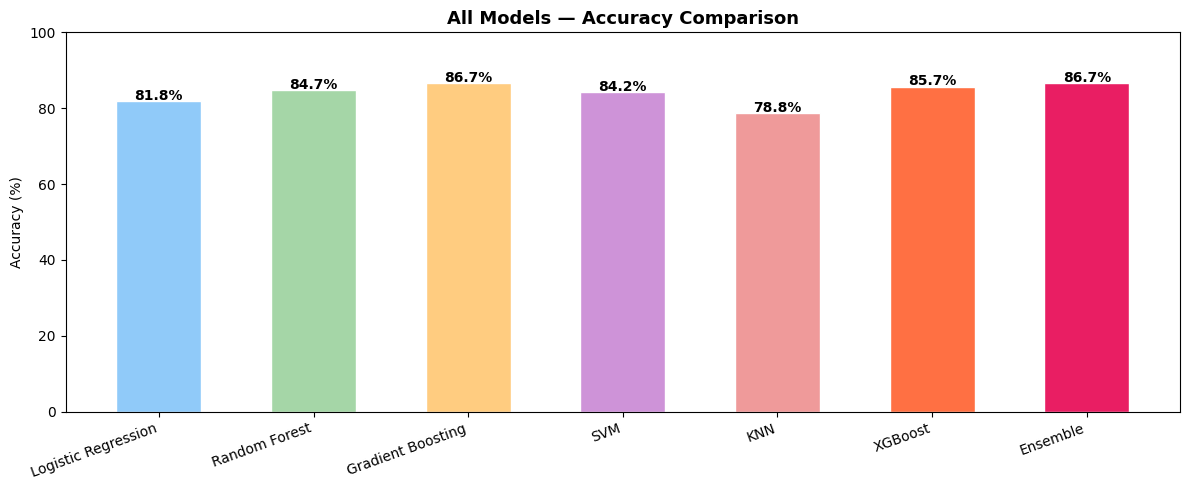


Best overall model: Gradient Boosting
Best accuracy: 86.70%


In [17]:
# All models comparison

all_models = {
    **{k: v['accuracy']*100 for k, v in results.items()},
    'XGBoost':  xgb_acc*100,
    'Ensemble': ens_acc*100
}

names_all  = list(all_models.keys())
accs_all   = list(all_models.values())
colors_all = [
    '#90CAF9','#A5D6A7','#FFCC80',
    '#CE93D8','#EF9A9A','#FF7043','#E91E63'
]

plt.figure(figsize=(12, 5))
bars = plt.bar(
    names_all, accs_all,
    color=colors_all, edgecolor='white', width=0.55
)
for bar, acc in zip(bars, accs_all):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{acc:.1f}%',
        ha='center', fontsize=10, fontweight='bold'
    )
plt.title(
    'All Models — Accuracy Comparison',
    fontsize=13, fontweight='bold'
)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150)
plt.show()

# Determine best model
best_overall = max(all_models, key=all_models.get)
print(f"\nBest overall model: {best_overall}")
print(f"Best accuracy: {all_models[best_overall]:.2f}%")

In [18]:
# Save best model and all components

import joblib

joblib.dump(ensemble,      'maternal_model.pkl')
joblib.dump(scaler,        'maternal_scaler.pkl')
joblib.dump(feature_cols,  'feature_cols.pkl')

# Save risk mapping
import json
with open('risk_mapping.json', 'w') as f:
    json.dump({
        '0': 'Low Risk',
        '1': 'Mid Risk',
        '2': 'High Risk'
    }, f)

print("All saved!")
print("Files:")
print("  maternal_model.pkl")
print("  maternal_scaler.pkl")
print("  feature_cols.pkl")
print("  risk_mapping.json")

All saved!
Files:
  maternal_model.pkl
  maternal_scaler.pkl
  feature_cols.pkl
  risk_mapping.json


Computing SHAP values for Random Forest...


<Figure size 1000x600 with 0 Axes>

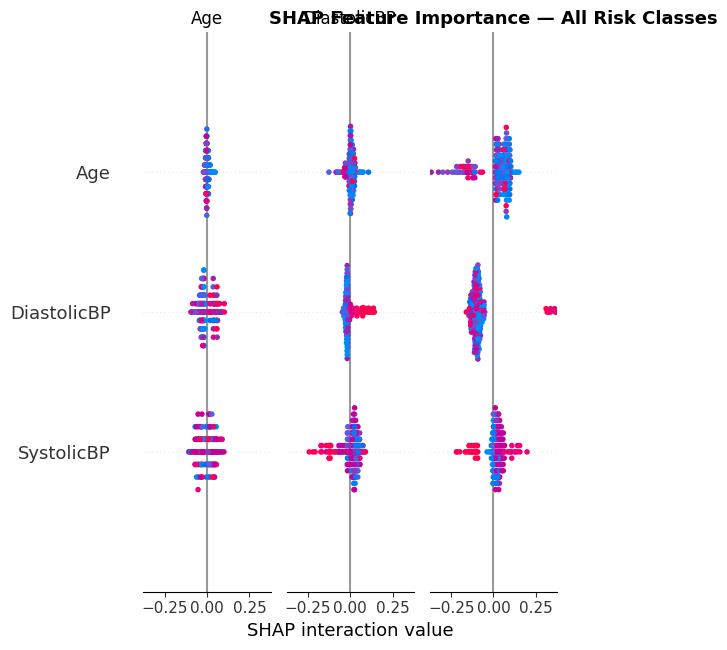

In [19]:
# Install and setup SHAP

!pip install shap -q

import shap
import numpy as np

print("Computing SHAP values for Random Forest...")

# Use Random Forest for SHAP — most interpretable
rf_model = results['Random Forest']['model']

explainer  = shap.TreeExplainer(rf_model)
shap_vals  = explainer.shap_values(X_test_sc)

# Feature importance plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals,
    X_test_sc,
    feature_names=feature_cols,
    class_names=['Low Risk','Mid Risk','High Risk'],
    show=False
)
plt.title(
    'SHAP Feature Importance — All Risk Classes',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150)
plt.show()

SHAP values type: <class 'numpy.ndarray'>
SHAP values length: 203
SHAP values shape: (203, 13, 3)


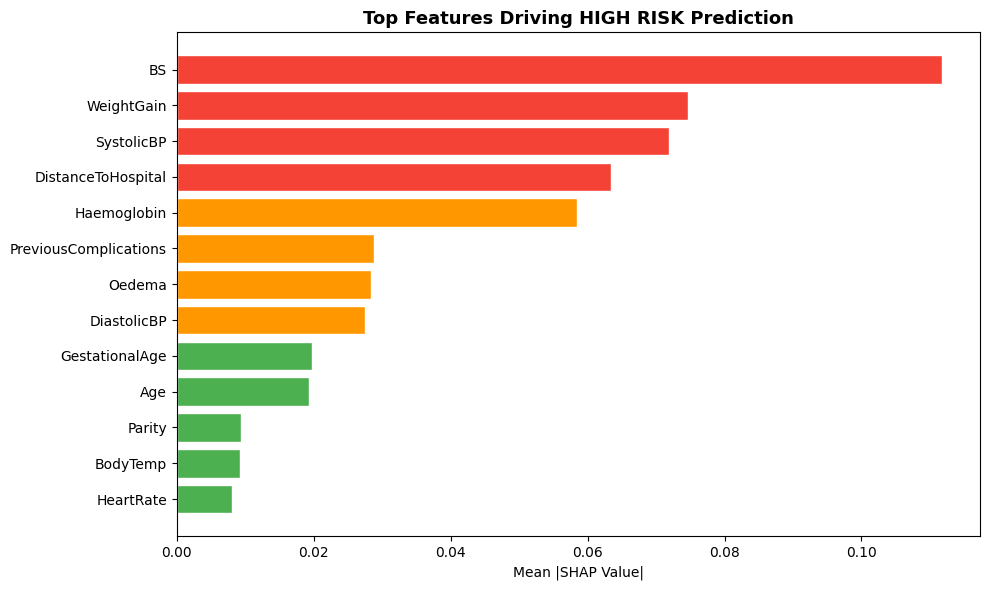


Top 7 features for HIGH RISK prediction:
  1. BS                       : 0.1117
  2. WeightGain               : 0.0746
  3. SystolicBP               : 0.0720
  4. DistanceToHospital       : 0.0634
  5. Haemoglobin              : 0.0584
  6. PreviousComplications    : 0.0288
  7. Oedema                   : 0.0284


In [20]:
# SHAP for High Risk class

import numpy as np
import matplotlib.pyplot as plt
import shap

# Check shape first
print("SHAP values type:", type(shap_vals))
print("SHAP values length:", len(shap_vals))
if isinstance(shap_vals, list):
    print("SHAP values[0] shape:", shap_vals[0].shape)
    print("SHAP values[2] shape:", shap_vals[2].shape)
else:
    print("SHAP values shape:", shap_vals.shape)

import pandas as pd
X_test_df = pd.DataFrame(X_test_sc, columns=feature_cols)

# ── Plot 1 — Bar chart of feature importance for High Risk ────
if isinstance(shap_vals, list):
    high_risk_shap = shap_vals[2]
else:
    high_risk_shap = shap_vals[:, :, 2]

mean_abs_shap = np.abs(high_risk_shap).mean(axis=0)

feat_imp = sorted(
    zip(feature_cols, mean_abs_shap),
    key=lambda x: x[1],
    reverse=True
)

feats  = [f[0] for f in feat_imp]
values = [f[1] for f in feat_imp]

plt.figure(figsize=(10, 6))
colors_bar = [
    '#F44336' if v > np.percentile(values, 70)
    else '#FF9800' if v > np.percentile(values, 40)
    else '#4CAF50'
    for v in values
]
bars = plt.barh(
    feats[::-1], values[::-1],
    color=colors_bar[::-1],
    edgecolor='white'
)
plt.title(
    'Top Features Driving HIGH RISK Prediction',
    fontsize=13, fontweight='bold'
)
plt.xlabel('Mean |SHAP Value|')
plt.tight_layout()
plt.savefig('shap_high_risk.png', dpi=150)
plt.show()

print("\nTop 7 features for HIGH RISK prediction:")
for i, (feat, imp) in enumerate(feat_imp[:7]):
    print(f"  {i+1}. {feat:25s}: {imp:.4f}")

=== High Risk Patient Profile ===
  Age                      : 40.00
  SystolicBP               : 120.00
  DiastolicBP              : 95.00
  BS                       : 11.00
  BodyTemp                 : 98.00
  HeartRate                : 80.00
  Haemoglobin              : 7.00
  GestationalAge           : 26.00
  Parity                   : 3.00
  Oedema                   : 1.00
  PreviousComplications    : 1.00
  DistanceToHospital       : 40.10
  WeightGain               : 2.90

Predicted: High Risk
Probabilities:
  Low Risk    : 0.0% 
  Mid Risk    : 6.5% █
  High Risk   : 93.5% ████████████████████████████


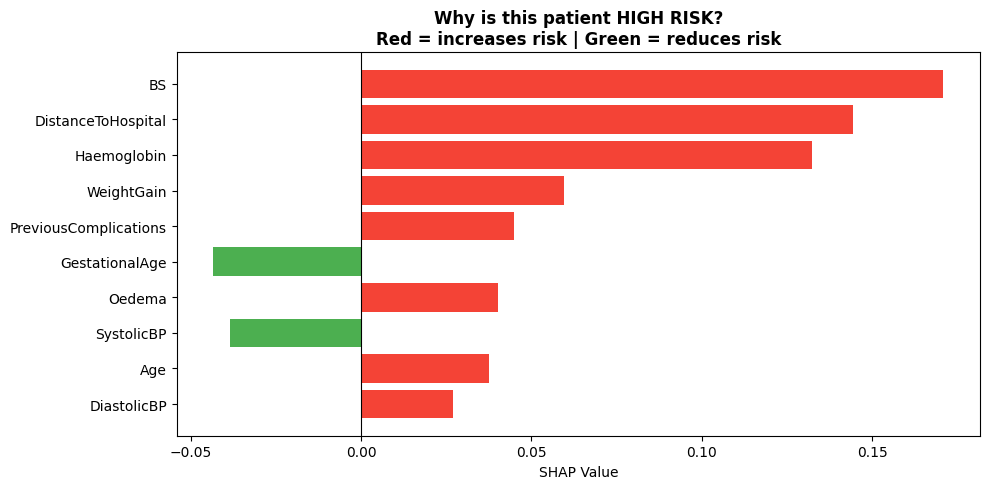

In [21]:
# Explain one high risk patient

import pandas as pd

# Find high risk patient
high_risk_idx = np.where(y_test.values == 2)[0][0]
patient_raw   = X_test.iloc[high_risk_idx]
patient_sc    = X_test_sc[high_risk_idx:high_risk_idx+1]

print("=== High Risk Patient Profile ===")
for feat, val in zip(feature_cols, patient_raw):
    print(f"  {feat:25s}: {val:.2f}")

# Prediction
pred_proba = rf_model.predict_proba(patient_sc)[0]
pred_class = rf_model.predict(patient_sc)[0]
risk_names = ['Low Risk', 'Mid Risk', 'High Risk']

print(f"\nPredicted: {risk_names[pred_class]}")
print("Probabilities:")
for name, prob in zip(risk_names, pred_proba):
    bar = '█' * int(prob * 30)
    print(f"  {name:12s}: {prob*100:.1f}% {bar}")

# SHAP bar chart for this patient
patient_shap = explainer.shap_values(patient_sc)

if isinstance(patient_shap, list):
    patient_shap_high = patient_shap[2][0]
else:
    patient_shap_high = patient_shap[0, :, 2]

# Plot
feat_shap = sorted(
    zip(feature_cols, patient_shap_high),
    key=lambda x: abs(x[1]),
    reverse=True
)[:10]

fp = [f[0] for f in feat_shap]
vp = [f[1] for f in feat_shap]
cp = ['#F44336' if v > 0 else '#4CAF50' for v in vp]

plt.figure(figsize=(10, 5))
plt.barh(fp[::-1], vp[::-1], color=cp[::-1])
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title(
    'Why is this patient HIGH RISK?\n'
    'Red = increases risk | Green = reduces risk',
    fontsize=12, fontweight='bold'
)
plt.xlabel('SHAP Value')
plt.tight_layout()
plt.savefig('shap_patient.png', dpi=150)
plt.show()

In [22]:
# Download all files

from google.colab import files

for fname in [
    'maternal_model.pkl',
    'maternal_scaler.pkl',
    'feature_cols.pkl',
    'risk_mapping.json',
    'shap_summary.png',
    'shap_high_risk.png',
    'shap_patient.png',
    'all_models_comparison.png',
    'asha_features.png'
]:
    try:
        files.download(fname)
        print(f"Downloaded: {fname}")
    except Exception as e:
        print(f"Skipped: {fname} — {e}")

print("\nAll done! Phase 7 complete.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: maternal_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: all_models_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: asha_features.png

All done! Phase 7 complete.
